In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
import gc
import time
#import matplotlib.pyplot as plt
#from livelossplot.keras import PlotLossesCallback
from tensorflow.keras.callbacks import ReduceLROnPlateau
#from keras.models import load_model
import csv
from itertools import chain
from matplotlib import pyplot as plt
import sklearn.metrics as metrics

D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\s

### 设置GPU显存按需分配

In [2]:
#如果没有装GPU版本，这部分就不用写，但是如果不用GPU加速计算，使用CPU将会严重限制模型的训练速度
gpus = tf.config.experimental.list_physical_devices('GPU') 
if gpus:
  try:

    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:

    print(e)

1 Physical GPUs, 1 Logical GPUs


### 载入数据

In [3]:
data_train=pd.read_csv('F:/TensorFlow/traindata20230508.csv',header=0,encoding='utf_8')
data_train.info()
data_train.ClassName.unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24660 entries, 0 to 24659
Columns: 257 entries, ClassName to Wgs84Y
dtypes: float64(26), int64(230), object(1)
memory usage: 48.4+ MB


array(['荒漠', '膜果麻黄（Ephedra przewalskii）荒漠', '盐爪爪（Kalidium foliatum）荒漠',
       '芨芨草（Achnatherum splendens）草甸', '矮生嵩草（Kobresia humilis）草甸',
       '垂穗披碱草（Elymus nutans）高寒草甸', '高山嵩草（Kobresia pygmaea）草甸',
       '高山薹草（Carex pseudosupina）草原', '紫花针茅（Stipa purpurea）草原',
       '早熟禾、垂穗披碱草高寒草甸', '线叶嵩草（Kobresia capillifolia）草甸',
       '金露梅（Potentilla fruticosa）灌丛', '鹅绒委陵菜（Potentilla anserina）高寒草甸',
       '垫状金露梅（Potentilla fruticosa var. pumila）灌丛',
       '藏北嵩草（Kobresia littledalei）沼泽草甸', '细叶嵩草（Kobresia filifolia）草甸',
       '扇穗茅（Littledalea racemosa）高寒草原',
       '藏嵩草（Kobresia vchaenoides=Kobresia tibetica）沼泽草甸',
       '青藏薹草（Carex moorcroftii）高寒草原', '嵩草（Kobresia spp.）草甸',
       '冰草（Agropyron cristatum）草原', '短花针茅（Stipa breviflora）荒漠草原',
       '芨芨草（Achnatherum splendens）草原', '赖草（Leymus secalinus）草甸',
       '长芒草（Stipa bungeana）草原', '沙生针茅（Stipa glareosa）荒漠草原',
       '华扁穗草（Blysmus sinocompressus）沼泽化草甸', '羊茅（Festuca ovina）杂类草草甸',
       '糙喙薹草（Carex scabrirostris）草甸', '小叶金露梅（Potentilla parvifo

In [4]:
pd.set_option('display.max_rows', None)
print(data_train['ClassName'].value_counts())

高山嵩草（Kobresia pygmaea）草甸                                                     5561
紫花针茅（Stipa purpurea）草原                                                       2067
矮生嵩草（Kobresia humilis）草甸                                                     1381
垂穗披碱草（Elymus nutans）高寒草甸                                                     1112
线叶嵩草（Kobresia capillifolia）草甸                                                 458
藏嵩草（Kobresia vchaenoides=Kobresia tibetica）沼泽草甸                               451
青藏薹草（Carex moorcroftii）高寒草原                                                   441
长芒草（Stipa bungeana）草原                                                         372
藏北嵩草（Kobresia littledalei）沼泽草甸                                                317
细叶早熟禾（Poa pratensis subsp. angustifolia）草甸草原                                  317
芨芨草（Achnatherum splendens）草原                                                  282
圆穗蓼（Polygonum macrophyllum）、珠芽蓼（Polygonum viviparum）高寒草甸                      266
沙生风毛菊（Saussurea 

In [5]:
data_train.head()

,ClassName,num,AET1901,AET1902,AET1903,AET1904,AET1905,AET1906,AET1907,AET1908,...,SR190829B7,SR190930B1,SR190930B2,SR190930B3,SR190930B4,SR190930B5,SR190930B6,SR190930B7,Wgs84X,Wgs84Y
0,荒漠,0,0,0,0,569,641,172,909,500,...,2315,3924,3623,2090,2492,2813,2333,1986,88.103636,28.158935
1,荒漠,0,0,0,0,569,641,172,909,500,...,2315,3924,3623,2090,2492,2813,2333,1986,88.103628,28.159233
2,荒漠,0,0,0,0,766,716,215,953,617,...,1790,1527,3059,1231,2011,3589,3697,3268,87.828855,28.327443
3,荒漠,0,0,0,0,56,1009,417,408,576,...,1717,1254,2300,931,1392,2789,2715,2324,83.346677,30.124012
4,荒漠,0,0,0,0,112,1093,358,224,233,...,980,828,1290,556,838,1670,1533,1175,84.919036,29.596544


In [6]:
# 生成该区间的随意唯一索引
index = np.random.permutation(len(data_train))
# 用生成的乱的索引就能将其打乱了
data_all = data_train.iloc[index ,:]

### 类别数量

In [7]:
num_classes = data_train['ClassName'].nunique()
print(num_classes)

140


### 切分数据集（已经提前切分的话不用此部分

In [8]:
split_index = int(len(data_all)*0.7)
data_train = data_all.iloc[:split_index]

data_test = data_all.iloc[split_index:]
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7398 entries, 2776 to 20127
Columns: 257 entries, ClassName to Wgs84Y
dtypes: float64(26), int64(230), object(1)
memory usage: 14.6+ MB


In [9]:
train_x = data_train.iloc[:,2:]
train_y = data_train.loc[:, ['num']] 

test_x = data_test.iloc[:,2:]
test_y = data_test.loc[:, ['num']] 

In [10]:
train_x.head(), train_y.head()

(       AET1901  AET1902  AET1903  AET1904  AET1905  AET1906  AET1907  AET1908  \
 8225         0        0        0        0      548      935      675      694   
 11452        0        0        0        0      261      884      906      838   
 12401        0        0      140      112      553      844      641      878   
 8007         0        0       55       27       74      174      146       55   
 12501        0        0        0       76      589      918      948      858   
 
        AET1909  AET1910  ...  SR190829B7  SR190930B1  SR190930B2  SR190930B3  \
 8225       567        0  ...        1335        1037        2287         451   
 11452      491        0  ...        1066        2642        3523        2682   
 12401      505      141  ...        1807        1046        2342         458   
 8007        56       26  ...        4219        2799        3093        1399   
 12501      526       34  ...        1108         879        1988         383   
 
        SR190930B4

### 顺序编码转独热编码

In [11]:
train_y = tf.keras.utils.to_categorical(train_y)

In [12]:
train_x.head()
train_y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

### 定义损失函数为Focal Loss

In [13]:
def multi_category_focal_loss2(gamma=2., alpha=.25):
    """
    focal loss for multi category of multi label problem
    适用于多分类或多标签问题的focal loss
    alpha控制真值y_true为1/0时的权重
        1的权重为alpha, 0的权重为1-alpha
    当你的模型欠拟合，学习存在困难时，可以尝试适用本函数作为loss
    当模型过于激进(无论何时总是倾向于预测出1),尝试将alpha调小
    当模型过于惰性(无论何时总是倾向于预测出0,或是某一个固定的常数,说明没有学到有效特征)
        尝试将alpha调大,鼓励模型进行预测出1。
    Usage:
     model.compile(loss=[multi_category_focal_loss2(alpha=0.25, gamma=2)], metrics=["accuracy"], optimizer='adam')
    """
    epsilon = 1.e-7
    gamma = float(gamma)
    alpha = tf.constant(alpha, dtype=tf.float32)

    def multi_category_focal_loss2_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    
        alpha_t = y_true*alpha + (tf.ones_like(y_true)-y_true)*(1-alpha)
        y_t = tf.multiply(y_true, y_pred) + tf.multiply(1-y_true, 1-y_pred)
        y_t = tf.clip_by_value(y_t, epsilon, 1. - epsilon)#这句是后加的
        ce = -tf.math.log(y_t)
        weight = tf.math.pow(tf.subtract(1., y_t), gamma)
        fl = tf.multiply(tf.multiply(weight, ce), alpha_t)
        loss = tf.reduce_mean(fl)
        return loss
    return multi_category_focal_loss2_fixed

### 模型构建

In [14]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(4096,input_dim=255))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(2048,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(1024,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(512,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(256,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(128,activation='relu'))
#model.add(tf.keras.layers.BatchNormalization())
#model.add(tf.keras.layers.Dense(64,activation='relu'))
#model.add(tf.keras.layers.BatchNormalization())
#model.add(tf.keras.layers.Dense(32,activation='relu'))#注：如果后面再加16，8，16，32这样的全连结层，精度反而会变低
model.add(tf.keras.layers.Dropout(rate=0.5))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))#不懂为啥有时候对不上非要+1
# 让学习率自动变化
reduce_lr = ReduceLROnPlateau(monitor='loss',factor=0.1, patience=20, mode='auto')
model.compile(loss='categorical_crossentropy', metrics=['acc'], optimizer='adam')#adam优化
#顺序编码用loss='sparse_categorical_crossentropy'
#独热编码用loss='categorical_crossentropy'
model.summary()

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 4096)              1048576   
_________________________________________________________________
batch_normalization (BatchNo (None, 4096)              16384     
_________________________________________________________________
dense_1 (Dense)              (None, 2048)              8390656   
____________________________________

### 开始训练

In [15]:
e = 300
start = time.perf_counter()#time.process_time()测的时间偏长
history = model.fit(train_x,train_y, epochs=e,batch_size=32,verbose=1,callbacks=[reduce_lr])#batch_size=16,validation_data=(validation_x,validation_y)
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

Epoch 1/300
17262/17262 [==============================] - 6s 323us/sample - loss: 5.4678 - acc: 0.1920
Epoch 2/300
17262/17262 [==============================] - 4s 255us/sample - loss: 3.7939 - acc: 0.2185
Epoch 3/300
17262/17262 [==============================] - 5s 273us/sample - loss: 3.5968 - acc: 0.2264
Epoch 4/300
17262/17262 [==============================] - 4s 252us/sample - loss: 3.4954 - acc: 0.2305
Epoch 5/300
17262/17262 [==============================] - 4s 247us/sample - loss: 3.4176 - acc: 0.2351
Epoch 6/300
17262/17262 [==============================] - 4s 256us/sample - loss: 3.3512 - acc: 0.2393
Epoch 7/300
17262/17262 [==============================] - 4s 252us/sample - loss: 3.2940 - acc: 0.2494
Epoch 8/300
17262/17262 [==============================] - 4s 257us/sample - loss: 3.2446 - acc: 0.2510
Epoch 9/300
17262/17262 [==============================] - 4s 255us/sample - loss: 3.1922 - acc: 0.2553
Epoch 10/300
17262/17262 [==============================] - 4s 2

17262/17262 [==============================] - 4s 243us/sample - loss: 1.6326 - acc: 0.5278
Epoch 80/300
17262/17262 [==============================] - 4s 238us/sample - loss: 1.6199 - acc: 0.5349
Epoch 81/300
17262/17262 [==============================] - 4s 237us/sample - loss: 1.6546 - acc: 0.5224
Epoch 82/300
17262/17262 [==============================] - 4s 242us/sample - loss: 1.6212 - acc: 0.5326
Epoch 83/300
17262/17262 [==============================] - 4s 238us/sample - loss: 1.6209 - acc: 0.5304
Epoch 84/300
17262/17262 [==============================] - 4s 242us/sample - loss: 1.5924 - acc: 0.5374
Epoch 85/300
17262/17262 [==============================] - 4s 247us/sample - loss: 1.5703 - acc: 0.5439
Epoch 86/300
17262/17262 [==============================] - 4s 240us/sample - loss: 1.6037 - acc: 0.5401
Epoch 87/300
17262/17262 [==============================] - 4s 251us/sample - loss: 1.5904 - acc: 0.5372
Epoch 88/300
17262/17262 [==============================] - 4s 251us

17262/17262 [==============================] - 4s 235us/sample - loss: 1.2497 - acc: 0.6250
Epoch 157/300
17262/17262 [==============================] - 4s 236us/sample - loss: 1.2860 - acc: 0.6181
Epoch 158/300
17262/17262 [==============================] - 4s 239us/sample - loss: 1.2454 - acc: 0.6290
Epoch 159/300
17262/17262 [==============================] - 4s 236us/sample - loss: 1.2388 - acc: 0.6304
Epoch 160/300
17262/17262 [==============================] - 4s 235us/sample - loss: 1.2249 - acc: 0.6276
Epoch 161/300
17262/17262 [==============================] - 4s 236us/sample - loss: 1.2347 - acc: 0.6292
Epoch 162/300
17262/17262 [==============================] - 4s 245us/sample - loss: 1.2417 - acc: 0.6280
Epoch 163/300
17262/17262 [==============================] - 4s 235us/sample - loss: 1.2344 - acc: 0.6321
Epoch 164/300
17262/17262 [==============================] - 4s 236us/sample - loss: 1.2273 - acc: 0.6331
Epoch 165/300
17262/17262 [==============================] -

17262/17262 [==============================] - 4s 237us/sample - loss: 1.0801 - acc: 0.6703
Epoch 234/300
17262/17262 [==============================] - 4s 236us/sample - loss: 1.0782 - acc: 0.6735
Epoch 235/300
17262/17262 [==============================] - 4s 241us/sample - loss: 1.0568 - acc: 0.6758
Epoch 236/300
17262/17262 [==============================] - 4s 240us/sample - loss: 1.0496 - acc: 0.6743
Epoch 237/300
17262/17262 [==============================] - 4s 236us/sample - loss: 1.0439 - acc: 0.6769
Epoch 238/300
17262/17262 [==============================] - 4s 237us/sample - loss: 1.0644 - acc: 0.6776
Epoch 239/300
17262/17262 [==============================] - 4s 235us/sample - loss: 1.0721 - acc: 0.6748
Epoch 240/300
17262/17262 [==============================] - 4s 238us/sample - loss: 1.0591 - acc: 0.6743
Epoch 241/300
17262/17262 [==============================] - 4s 235us/sample - loss: 1.0671 - acc: 0.6766
Epoch 242/300
17262/17262 [==============================] -

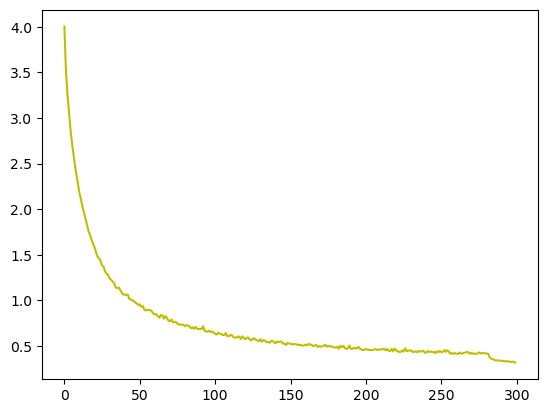

In [21]:
plt.plot(range(300),history.history.get('loss'),color =  'y')

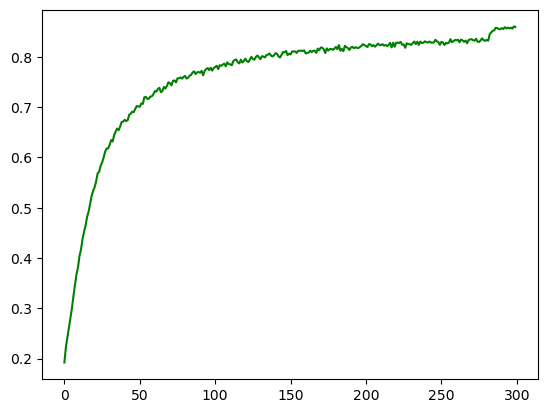

In [22]:
plt.plot(range(300),history.history.get('acc'),color =  'g')

In [17]:
model.save(r'F:/TensorFlow/model_data/model_QTP_20231008.h5')

### 计算准确率

In [23]:
test_r = pd.DataFrame(model.predict_classes(test_x,verbose=1))
test_r = test_r.values
acc_array = (test_y == test_r)
print('准确率：', np.sum(acc_array!=0)/len(acc_array))

7398/7398 [==============================] - 0s 50us/sample
准确率： num    0.720059
dtype: float64


In [30]:
test_r_arr = test_r.flatten()
test_y_arr = test_y['num'].to_numpy()
print(test_r_arr, test_y_arr)

In [39]:
print('准确率accuracy: ')
print(metrics.accuracy_score(test_y_arr, test_r_arr))
print(metrics.accuracy_score(test_y_arr, test_r_arr, normalize=False))
print('精确率precision: ')
print(metrics.precision_score(test_y_arr, test_r_arr, average='macro'))
print(metrics.precision_score(test_y_arr, test_r_arr, average='micro'))
print(metrics.precision_score(test_y_arr, test_r_arr, average='weighted'))
# print(metrics.precision_score(test_y_arr, test_r_arr, average=None))
print('召回率recall: ')
print(metrics.recall_score(test_y_arr, test_r_arr, average='macro'))
print(metrics.recall_score(test_y_arr, test_r_arr, average='micro'))
print(metrics.recall_score(test_y_arr, test_r_arr, average='weighted'))
# print(metrics.recall_score(test_y_arr, test_r_arr, average=None))
print('F1 score: ')
print(metrics.f1_score(test_y_arr, test_r_arr, average='macro'))
print(metrics.f1_score(test_y_arr, test_r_arr, average='micro'))
print(metrics.f1_score(test_y_arr, test_r_arr, average='weighted'))
# print(metrics.f1_score(test_y_arr, test_r_arr, average=None))

准确率accuracy: 
0.7200594755339281
5327
精确率precision: 
0.7995874257523369
0.7200594755339281
0.7155776373620245
召回率recall: 
0.8496534315216796
0.7200594755339281
0.7200594755339281
F1 score: 
0.8161179767923975
0.720059475533928
0.7133072086586109


### 各类别准确率

In [40]:
print(metrics.classification_report(test_y_arr, test_r_arr))

              precision    recall  f1-score   support

           0       1.00      0.87      0.93        39
           1       1.00      0.44      0.62         9
           2       0.58      0.63      0.60        30
           3       0.59      0.66      0.62        35
           4       0.64      0.60      0.62       399
           5       0.57      0.46      0.51       333
           6       0.73      0.72      0.72      1673
           7       0.80      0.32      0.46        25
           8       0.62      0.55      0.58       629
           9       0.94      1.00      0.97        15
          10       0.61      0.54      0.57       168
          11       0.71      0.43      0.53        56
          12       0.38      0.36      0.37        44
          13       0.94      1.00      0.97        45
          14       0.39      0.32      0.35        88
          15       0.58      0.68      0.62        28
          16       0.81      1.00      0.90        26
          17       0.61    

In [32]:
test_y = list(chain.from_iterable(test_y))
test_r = list(chain.from_iterable(test_r))

def count_nums(true_labels, num_classes):
    initial_value = 0
    list_length = num_classes
    list_data = [ initial_value for i in range(list_length)]
    for i in range(0, num_classes):
        list_data[i] = true_labels.count(i)
    return list_data

def accuracy(confusion_matrix, true_labels, num_classes):
    # 各个类别的测试样本的个数
    list_data = count_nums(true_labels, num_classes)
 
    # 各个类别正确分类的个数
    initial_value = 0
    list_length = num_classes
    true_pred = [ initial_value for i in range(list_length)]
    for i in range(0,num_classes):
        true_pred[i] = confusion_matrix[i][i]
 
    # 计算各个样本被正确分类的正确率
    classveg = []
    acc = []
    for i in range(0, num_classes):
        classveg.append(0)
        acc.append(0)
 
    for i in range(0,num_classes):
        classveg[i] = i
        acc[i] = float(true_pred[i] / list_data[i])
    
    z = pd.DataFrame(list(zip(classveg,acc,list_data)), columns=['class_code', 'acc','count'])
    return z

op = tf.math.confusion_matrix(test_y, test_r)

acc = accuracy(op, test_y, num_classes)
print(acc)

ValueError: Dimension 0 in both shapes must be equal, but are 3 and 7398. Shapes are [3] and [7398].
	From merging shape 0 with other shapes. for 'confusion_matrix/stack_1' (op: 'Pack') with input shapes: [3], [7398].